# KMeans Model - CIS 2450 Final Project
K-Means on Joined OpenAlex + Semantic Scholar Data

This notebook joins `openalex_papers` with `semanticscholar_papers`, filters out rows with missing abstracts or TLDRs, vectorizes the text, and clusters the papers with K-Means.

## Setup

In [18]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from scipy.sparse import csr_matrix, hstack
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler


## Load Data

In [20]:
# Load the joined dataset and keep only rows with a stored abstract vector and TLDR text
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.abstract_tfidf_vector,
    s.tldr_text
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_text IS NOT NULL
  AND TRIM(s.abstract_text) <> ''
  AND s.abstract_tfidf_vector IS NOT NULL
  AND TRIM(s.abstract_tfidf_vector) <> ''
  AND s.tldr_text IS NOT NULL
  AND TRIM(s.tldr_text) <> ''
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Joined rows with abstract vector + TLDR: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Joined rows with abstract vector + TLDR: 15042
Columns: 14


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,abstract_tfidf_vector,tldr_text
str,str,str,str,i64,i64,i64,str,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""{""dimension"": 2000, ""indices"":…","""It is revealed that current sp…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""{""dimension"": 2000, ""indices"":…","""A comprehensive threat taxonom…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""{""dimension"": 2000, ""indices"":…","""This survey provides an in-dep…"
"""https://openalex.org/W43969140…","""https://doi.org/10.1007/s11263…","""10.1007/s11263-025-02646-6""","""Deep Learning-Based Object Pos…",2026,14,10,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""","""Computer Science""","""Physical Sciences""","""Object pose estimation is a fu…","""{""dimension"": 2000, ""indices"":…","""This survey discusses the rece…"
"""https://openalex.org/W44043502…","""https://doi.org/10.1038/s41567…","""10.1038/s41567-025-03144-9""","""Dynamical simulations of many-…",2026,9,19,"""Neural Networks and Reservoir …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Quantum circuits with local un…","""{""dimension"": 2000, ""indices"":…","""This work studies dual-unitary…"


In [21]:
# Build the structured feature block in Polars
year_median = df["publication_year"].drop_nulls().median()

structured_df = df.select([
    pl.col("publication_year").fill_null(year_median).cast(pl.Float64),
    pl.col("cited_by_count").fill_null(0).clip(lower_bound=0).log1p(),
    pl.col("author_count").fill_null(0).clip(lower_bound=0).log1p(),
    pl.col("primary_topic").fill_null("Unknown"),
    pl.col("primary_subfield").fill_null("Unknown"),
    pl.col("primary_field").fill_null("Unknown"),
    pl.col("primary_domain").fill_null("Unknown"),
])

structured_encoded = structured_df.to_dummies(columns=[
    "primary_topic",
    "primary_subfield",
    "primary_field",
    "primary_domain",
])

structured_matrix = structured_encoded.to_numpy()
structured_matrix = StandardScaler().fit_transform(structured_matrix)
structured_matrix = csr_matrix(structured_matrix)

print("Structured matrix shape:", structured_matrix.shape)


Structured matrix shape: (15042, 286)


In [22]:
# Load precomputed abstract TF-IDF vectors and vectorize TLDR text
def stored_tfidf_vectors_to_csr(vector_jsons):
    data = []
    indices = []
    indptr = [0]
    dimension = None

    for vector_json in vector_jsons:
        vector = json.loads(vector_json)
        vector_dimension = vector["dimension"]
        if dimension is None:
            dimension = vector_dimension
        elif dimension != vector_dimension:
            raise ValueError("Stored abstract TF-IDF vectors have inconsistent dimensions")

        indices.extend(vector["indices"])
        data.extend(vector["values"])
        indptr.append(len(indices))

    return csr_matrix((data, indices, indptr), shape=(len(vector_jsons), dimension or 0))

tldr_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=750,
    min_df=3,
)

abstract_matrix = stored_tfidf_vectors_to_csr(df["abstract_tfidf_vector"].to_list())
tldr_matrix = tldr_vectorizer.fit_transform(df["tldr_text"].to_list())

print("Abstract TF-IDF shape:", abstract_matrix.shape)
print("TLDR TF-IDF shape:", tldr_matrix.shape)


Abstract TF-IDF shape: (15042, 2000)
TLDR TF-IDF shape: (15042, 750)


In [23]:
# Combine structured and text features into one sparse matrix
X = hstack([
    structured_matrix,
    abstract_matrix,
    tldr_matrix,
], format="csr")

print("Combined feature matrix shape:", X.shape)


Combined feature matrix shape: (15042, 3036)


## Fit K-Means

In [24]:
# Fit K-Means on the combined feature matrix
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X)

print(kmeans_model)
pl.DataFrame({"cluster": clusters}).group_by("cluster").len().sort("cluster")

KMeans(n_clusters=5, n_init=10, random_state=42)


cluster,len
i32,u32
0,13610
1,65
2,34
3,275
4,1058


In [25]:
# Add cluster labels back to the joined dataframe
df_clustered = df.with_columns(pl.Series("cluster", clusters))

df_clustered.select([
    "title",
    "publication_year",
    "primary_topic",
    "primary_subfield",
    "cluster",
]).head(10)

title,publication_year,primary_topic,primary_subfield,cluster
str,i64,str,str,i32
"""RFAConv: Receptive-field atten…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…",0
"""Model Context Protocol (MCP): …",2026,"""Security and Verification in C…","""Artificial Intelligence""",0
"""Graph Transformers: A Survey""",2026,"""Advanced Graph Neural Networks""","""Artificial Intelligence""",0
"""Deep Learning-Based Object Pos…",2026,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""",0
"""Dynamical simulations of many-…",2026,"""Neural Networks and Reservoir …","""Artificial Intelligence""",0
"""Deep contrastive learning enab…",2026,"""Computational Drug Discovery M…","""Computational Theory and Mathe…",4
"""Interval cancer, sensitivity, …",2026,"""AI in cancer detection""","""Artificial Intelligence""",0
"""SAM2-UNet: segment anything 2 …",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…",0
"""What is wrong with your code g…",2026,"""Software Engineering Research""","""Information Systems""",0


## Predict nearby papers from a given paper

Use the fitted K-Means model to predict the selected paper's cluster, then rank papers inside that cluster by cosine similarity in the same combined feature space used for clustering.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

PAPER_LOOKUP_COLUMNS = [
    "title",
    "doi",
    "doi_normalized",
    "openalex_id",
]

In [ ]:
def find_paper_index(paper, papers_df=df_clustered):
    """Return the row index for a paper given a row number, DOI, OpenAlex ID, or title text."""
    if isinstance(paper, int):
        if 0 <= paper < papers_df.height:
            return paper
        raise ValueError(f"Paper row index {paper} is outside 0..{papers_df.height - 1}")

    query = str(paper).strip().lower()
    if not query:
        raise ValueError("Please provide a non-empty paper title, DOI, OpenAlex ID, or row index.")

    records = papers_df.select(PAPER_LOOKUP_COLUMNS).to_dicts()

    # Prefer exact identifier/title matches.
    for idx, record in enumerate(records):
        for column in PAPER_LOOKUP_COLUMNS:
            value = record.get(column)
            if value is not None and str(value).strip().lower() == query:
                return idx

    # Fall back to a title substring search for easier notebook demos.
    title_matches = [
        idx
        for idx, record in enumerate(records)
        if record.get("title") is not None and query in str(record["title"]).lower()
    ]
    if len(title_matches) == 1:
        return title_matches[0]
    if len(title_matches) > 1:
        matches = papers_df[title_matches].select(["title", "doi_normalized", "publication_year"])
        raise ValueError(f"Found {len(title_matches)} title matches. Use a row index or DOI to disambiguate:\n{matches}")

    raise ValueError(f"No paper found for: {paper}")

In [ ]:
def predict_nearby_papers(paper, n=10, same_cluster_only=True, include_query=False):
    """Find nearby papers for an existing paper in the modeled dataset.

    Parameters
    ----------
    paper : int or str
        Row index, DOI, normalized DOI, OpenAlex ID, exact title, or title substring.
    n : int
        Number of nearby papers to return.
    same_cluster_only : bool
        If True, only rank papers assigned to the K-Means cluster predicted for the query paper.
        If False, rank every paper in the dataset by cosine similarity.
    include_query : bool
        If True, include the input paper itself in the returned table.
    """
    query_idx = find_paper_index(paper)
    query_vector = X[query_idx]
    predicted_cluster = int(kmeans_model.predict(query_vector)[0])

    if same_cluster_only:
        candidate_indices = [
            idx
            for idx, cluster in enumerate(clusters)
            if int(cluster) == predicted_cluster
        ]
    else:
        candidate_indices = list(range(X.shape[0]))

    similarities = cosine_similarity(query_vector, X[candidate_indices]).ravel()
    ranked = sorted(
        zip(candidate_indices, similarities),
        key=lambda item: item[1],
        reverse=True,
    )

    if not include_query:
        ranked = [(idx, score) for idx, score in ranked if idx != query_idx]

    top = ranked[:n]
    if not top:
        return pl.DataFrame()

    result_indices = [idx for idx, _ in top]
    result_scores = [float(score) for _, score in top]

    return (
        df_clustered[result_indices]
        .with_columns(pl.Series("similarity_to_query", result_scores))
        .select([
            "similarity_to_query",
            "cluster",
            "title",
            "publication_year",
            "primary_topic",
            "primary_subfield",
            "doi",
            "openalex_id",
        ])
    )


# Example: use any title/DOI/OpenAlex ID from df_clustered, or pass a row index.
example_paper = df_clustered[0, "title"]
print(f"Query paper: {example_paper}")
predict_nearby_papers(example_paper, n=5)


Query paper: RFAConv: Receptive-field attention convolution for improving convolutional neural networks


similarity_to_query,cluster,title,publication_year,primary_topic,primary_subfield,doi,openalex_id
f64,i32,str,i64,str,str,str,str
0.947084,0,"""SAM2-UNet: segment anything 2 …",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""https://doi.org/10.1007/s44267…","""https://openalex.org/W71238841…"
0.908931,0,"""Semi-Supervised Object Detecti…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""https://doi.org/10.3390/s26010…","""https://openalex.org/W71181744…"
0.872895,0,"""HGQ: High Granularity Quantiza…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""https://doi.org/10.1145/374817…","""https://openalex.org/W43966506…"
0.811432,0,"""A Lightweight Upsampling and C…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""https://doi.org/10.3390/electr…","""https://openalex.org/W71202422…"
0.811045,0,"""<scp>DSGNet</scp> : A Lightwei…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""https://doi.org/10.1111/exsy.7…","""https://openalex.org/W71181806…"


## Evaluate

In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters, sample_size=2000, random_state=42)
print(f"Silhouette score: {score:.4f}")


Silhouette score: -0.1991


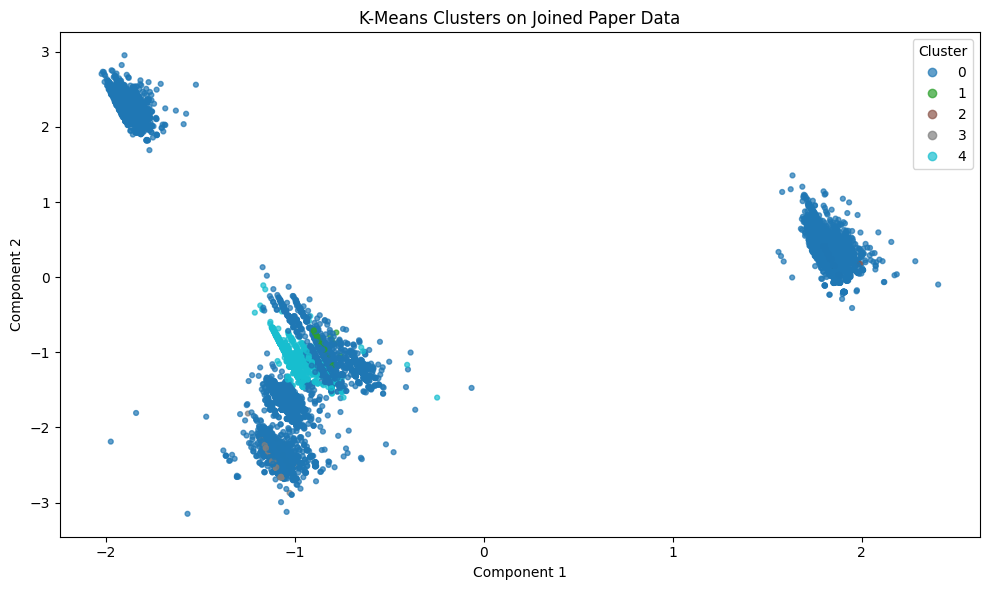

Explained variance ratio: [0.00878317 0.00783263]


In [28]:
# Project the sparse text-heavy matrix to 2D for visualization
# TruncatedSVD is the PCA-style reduction commonly used for sparse TF-IDF data.
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=clusters,
    cmap="tab10",
    s=12,
    alpha=0.7,
)
plt.title("K-Means Clusters on Joined Paper Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", svd.explained_variance_ratio_)


In [29]:
# Compare multiple values of k using inertia and sampled silhouette score
k_values = range(2, 11)
results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=2000, random_state=42)
    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": score,
    })
    print(f"k={k}: inertia={model.inertia_:.2f}, silhouette={score:.4f}")

results_df = pl.DataFrame(results)
results_df

k=2: inertia=4260636.71, silhouette=0.1820
k=3: inertia=4245353.36, silhouette=0.1843
k=4: inertia=4224073.08, silhouette=-0.2532
k=5: inertia=4195578.48, silhouette=-0.1991
k=6: inertia=4175654.46, silhouette=-0.0631
k=7: inertia=4153664.90, silhouette=-0.1199
k=8: inertia=4156300.87, silhouette=-0.1860
k=9: inertia=4125294.82, silhouette=-0.0741
k=10: inertia=4102248.84, silhouette=-0.1753


k,inertia,silhouette_score
i64,f64,f64
2,4.2606e6,0.182047
3,4.2454e6,0.184305
4,4.2241e6,-0.253205
5,4.1956e6,-0.19908
6,4.1757e6,-0.063052
7,4.1537e6,-0.119864
8,4.1563e6,-0.186009
9,4.1253e6,-0.074116
10,4.1022e6,-0.175251


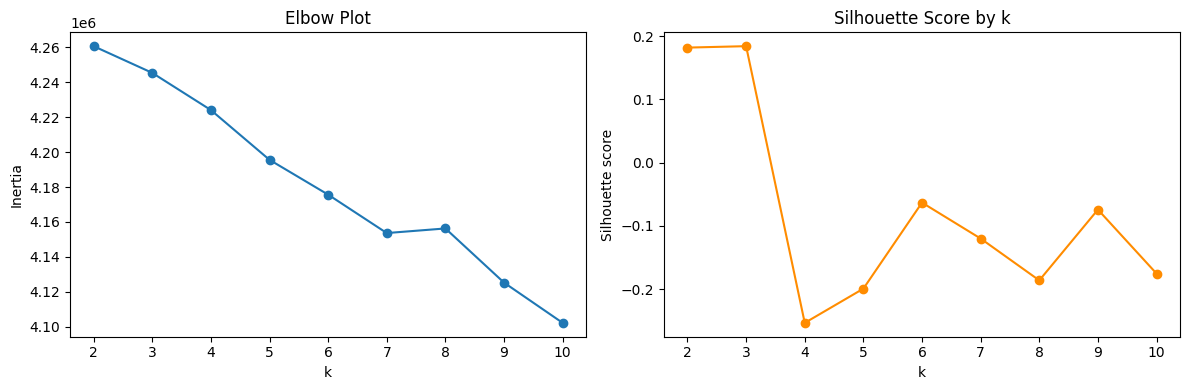

In [30]:
# Plot inertia and silhouette score across k values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df["k"].to_list(), results_df["inertia"].to_list(), marker="o")
axes[0].set_title("Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    results_df["k"].to_list(),
    results_df["silhouette_score"].to_list(),
    marker="o",
    color="darkorange",
)
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

Comments: The K-Means model performs very poorly. A silhouette score below 0 means many points are closer to another cluster than they one they are assigned! Vectorizing the tldrs and abstracts definitely causes some sort of curse of dimensionality. Clearly there are only 3 clusters but that may be because of topic clustering rather than the actual structure of the data. We will likely need a different strategy for parsing information out of tldrs and abstracts like keyword search (or ditch it all together, which could be detrimental because then we do not have any measure of the content of the paper). We also may need to consider changing the model we're choosing altogether. KMeans and PCA is visually useful, but in this case the data does not seem suited to clustering.